In [21]:
import warnings
warnings.filterwarnings("ignore")

In [22]:
pip install PyPDF2


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


## To extract text from the given PDF file and convert it into a usable text corpus for analysis.

In [3]:
import PyPDF2

pdf_path = "PDF1.pdf"
raw_text = ""

with open(pdf_path, "rb") as file:
    reader = PyPDF2.PdfReader(file)
    for page in reader.pages:
        raw_text += page.extract_text()

# Save extracted text
with open("extracted_text.txt", "w", encoding="utf-8") as f:
    f.write(raw_text)

print("PDF successfully converted to text!")

PDF successfully converted to text!


## To clean and normalize the extracted text by removing noise and converting words into their base form.

## Convert text to lowercase

## Remove punctuation and numbers

## Tokenize the text

## Remove stop words

## Apply lemmatization

In [4]:
import spacy
import re

nlp = spacy.load("en_core_web_sm")

# Clean unwanted characters
text = re.sub(r'\s+', ' ', raw_text)
text = re.sub(r'[^a-zA-Z\s]', '', text).lower()

doc = nlp(text)

clean_tokens = [
    token.lemma_ for token in doc 
    if not token.is_stop and not token.is_punct and len(token.text) > 2
]

processed_text = " ".join(clean_tokens)

print("Text preprocessing completed!")

Text preprocessing completed!


## To calculate the frequency of each word appearing in the processed text.

            Word  Frequency
44       opinion        162
60       feature        160
69      sentence        133
245  orientation        105
247         word         89
3         review         87
21       product         86
246    adjective         52
62      positive         37
314       phrase         36
63      negative         35
58          text         34
227                      34
179         work         33
2       customer         33


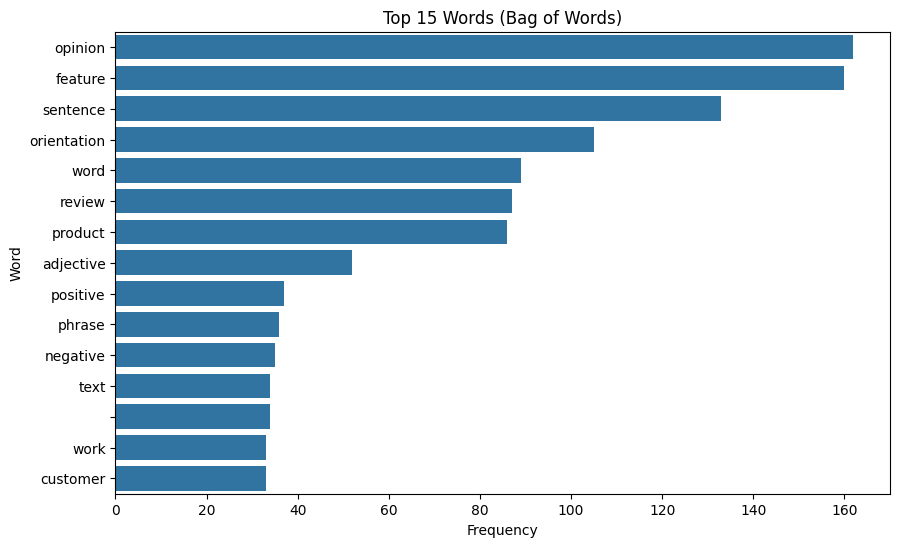

In [5]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

word_freq = Counter(clean_tokens)

bow_df = pd.DataFrame(word_freq.items(), columns=["Word", "Frequency"])
bow_df = bow_df.sort_values(by="Frequency", ascending=False)

print(bow_df.head(15))

plt.figure(figsize=(10,6))
sns.barplot(x="Frequency", y="Word", data=bow_df.head(15))
plt.title("Top 15 Words (Bag of Words)")
plt.show()

## To identify the most important words in the document by assigning weights based on frequency and uniqueness.

             TF-IDF Score
opinion          0.470789
feature          0.464977
sentence         0.386512
orientation      0.305141
word             0.258643
review           0.252831
product          0.249925
adjective        0.151117
positive         0.107526
phrase           0.104620
negative         0.101714
text             0.098808
work             0.095901
customer         0.095901
result           0.095901
find             0.092995
use              0.084277
express          0.078465
technique        0.075559
summary          0.075559


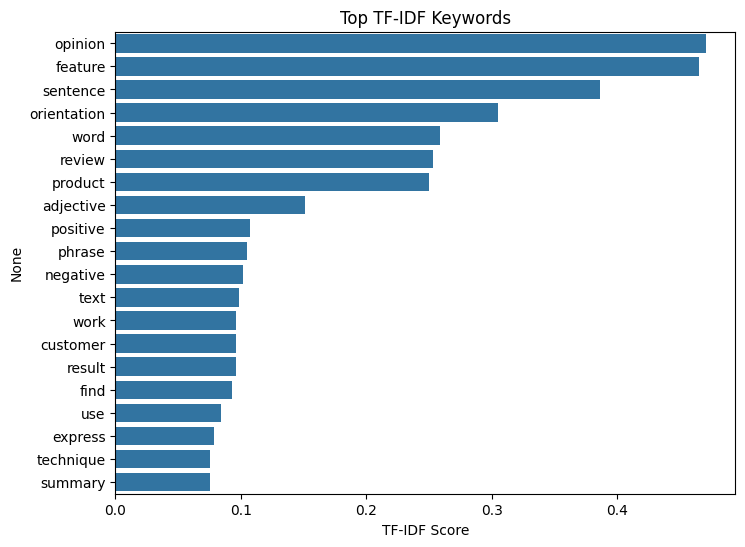

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20)

tfidf_matrix = tfidf.fit_transform([processed_text])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
).T

tfidf_df.columns = ["TF-IDF Score"]
tfidf_df = tfidf_df.sort_values(by="TF-IDF Score", ascending=False)

print(tfidf_df)

plt.figure(figsize=(8,6))
sns.barplot(x=tfidf_df["TF-IDF Score"], y=tfidf_df.index)
plt.title("Top TF-IDF Keywords")
plt.show()

In [7]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


## To determine the emotional tone of the extracted business text.

In [8]:
from textblob import TextBlob

blob = TextBlob(processed_text)

polarity = blob.sentiment.polarity
subjectivity = blob.sentiment.subjectivity

print("Polarity:", polarity)
print("Subjectivity:", subjectivity)

if polarity > 0:
    sentiment = "Positive"
elif polarity < 0:
    sentiment = "Negative"
else:
    sentiment = "Neutral"

print("Overall Sentiment:", sentiment)

Polarity: 0.0681492910758966
Subjectivity: 0.49191475038722726
Overall Sentiment: Positive


In [9]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


## To visualize the most frequent and important words in the business text.

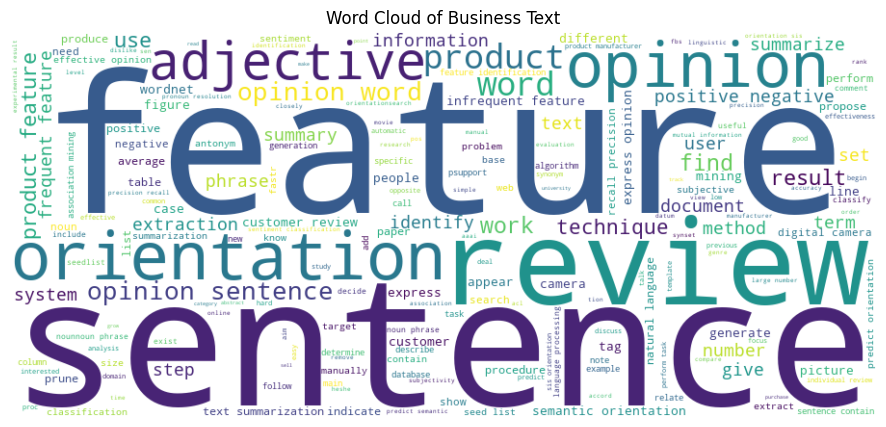

In [10]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=900,
    height=400,
    background_color="white",
    colormap="viridis"
).generate(processed_text)

plt.figure(figsize=(12,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Business Text")
plt.show()

## Conclusion